## **Project:** Students Wellbeing/Performance Analyzer

**Description:** This project analyzes student wellbeing data using Pandas and Seaborn. The project aims to clean the data, visualize trends, and perform statistical analyses.

## Class and function definitions

In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt

class StudentWellbeingAnalyzer:
    def __init__(self, file_path: str):
        """Load dataset and show preview"""
        self.df = pd.read_csv(file_path)
        print("Preview:\n", self.df.head())

    def summarize_missing_values(self):
        """Summarize missing values"""
        print("\nMissing values:\n", self.df.isnull().sum())

    def clean_data(self):
        """Handle missing values and ensure correct types"""
        self.df.dropna(subset=['GPA', 'Program'], inplace=True)

        numeric_cols = ['StudyHours', 'SleepHours', 'ExerciseHours', 'SocialMediaHours',
                        'MoodLevel', 'StressLevel', 'AttendanceRate (%)']
        for col in numeric_cols:
            self.df.loc[:, col] = self.df[col].fillna(self.df[col].median())

        self.df['GPA'] = self.df['GPA'].astype(float)
        self.df['AttendanceRate (%)'] = self.df['AttendanceRate (%)'].astype(float)

    def assign_letter_grades(self):
        """Create Letter Grade column from GPA, assuming 4.0 max GPA"""
        def grade(g: float) -> str:
            percent = g * 25  # scale 4.0 to 100
            if percent >= 90: return 'A'
            elif percent >= 85: return 'A-'
            elif percent >= 80: return 'B+'
            elif percent >= 75: return 'B'
            elif percent >= 70: return 'B-'
            elif percent >= 65: return 'C+'
            elif percent >= 60: return 'C'
            elif percent >= 55: return 'C-'
            elif percent >= 50: return 'D+'
            elif percent >= 45: return 'D'
            elif percent >= 40: return 'D-'
            else: return 'F'
        
        self.df['LetterGrade'] = self.df['GPA'].apply(grade)


    def compute_wellbeing_score(self):
        """Create WellbeingScore (0–100) based on normalized indicators"""
        df = self.df
        df['SleepScore'] = df['SleepHours'] / 9
        df['ExerciseScore'] = df['ExerciseHours'] / 7
        df['MoodScore'] = df['MoodLevel'] / 10
        df['StressScore'] = 1 - (df['StressLevel'] / 10)
        df['SocialMediaScore'] = 1 - (df['SocialMediaHours'] / 8)
        df['StudyScore'] = df['StudyHours'] / 20

        df['WellbeingScore'] = (
            0.2 * df['SleepScore'] +
            0.2 * df['ExerciseScore'] +
            0.2 * df['MoodScore'] +
            0.2 * df['StressScore'] +
            0.1 * df['SocialMediaScore'] +
            0.1 * df['StudyScore']
        ) * 100

    def univariate_analysis(self):
        """Plot histograms for StudyHours, GPA, MoodLevel, StressLevel"""
        cols = ['StudyHours', 'GPA', 'MoodLevel', 'StressLevel']
        for col in cols:
            sns.histplot(self.df[col], kde=True)
            plt.title(f'{col} Distribution')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.show()

    def bivariate_analysis(self):
        """Scatterplots and heatmaps to explore relationships"""
        sns.scatterplot(data=self.df, x='StudyHours', y='GPA')
        plt.title("Study Hours vs GPA")
        plt.show()

        sns.scatterplot(data=self.df, x='SleepHours', y='GPA')
        plt.title("Sleep Hours vs GPA")
        plt.show()

        heatmap_data = self.df[['SleepHours', 'ExerciseHours', 'MoodLevel',
                                'StressLevel', 'SocialMediaHours']]
        sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm')
        plt.title("Wellbeing Indicators Correlation Matrix")
        plt.show()

    def compare_academic_performance(self):
        """Compare GPA across Program and Gender"""
        sns.barplot(data=self.df, x='Program', y='GPA', hue='Gender')
        plt.xticks(rotation=45)
        plt.title("GPA by Program and Gender")
        plt.show()

    def key_insights(self):
        """Print 5 meaningful findings from EDA"""
        print("\nKey Insights:")
        print("1. Students who study more tend to have higher GPA.")
        print("2. Better mood and more sleep relate to lower stress.")
        print("3. Higher social media use slightly lowers WellbeingScore.")
        print("4. Female students show slightly better GPA overall.")
        print("5. Students in AI and Data Science show higher wellbeing and grades.")

    def export_cleaned_data(self, out_file: str):
        """Save cleaned and transformed dataset for dashboard use"""
        self.df.to_csv(out_file, index=False)
        print(f"Cleaned data saved to: {out_file}")

## Load Dataset and Preview

In [2]:
analyzer = StudentWellbeingAnalyzer("student_wellbeing_final.csv")

Preview:
    StudentID      Name  Age Gender       Program   GPA  StudyHours  \
0       1001    Robert   24      M  Applications  2.73        10.0   
1       1002  Jennifer   32      F  Applications   NaN        19.0   
2       1003   Charles   28      M  Applications  2.89         1.0   
3       1004    Robert   25      M  Applications  3.19        14.0   
4       1005    Joseph   24    NaN  Data Science  2.28        13.0   

   SleepHours  ExerciseHours  SocialMediaHours  MoodLevel  StressLevel  \
0         6.0            6.0                 5         10            6   
1         6.0            4.0                 4          2            3   
2         9.0            0.0                 5          9            9   
3         9.0            5.0                 6         10            7   
4         8.0            4.0                 1          5            1   

   AttendanceRate (%)  
0               92.80  
1               87.80  
2               81.30  
3               77.95  
4   

#### Load and Preview Dataset
I initialized the analyzer by loading the dataset and previewing the first few records to understand the structure.

## Summarize Missing Values

In [3]:
analyzer.summarize_missing_values()


Missing values:
 StudentID              0
Name                   0
Age                    0
Gender                34
Program                0
GPA                   24
StudyHours            24
SleepHours            24
ExerciseHours         24
SocialMediaHours       0
MoodLevel              0
StressLevel            0
AttendanceRate (%)    24
dtype: int64


#### Summarize Missing Values
This step helps identify columns with missing values that could impact analysis or require imputation or removal.

## Clean Data

In [4]:
analyzer.clean_data()

#### Clean Dataset

 - Dropped rows missing critical values like GPA and Program.

- Filled missing numeric fields using median values to maintain data consistency.

- Converted data types (e.g., GPA and AttendanceRate) to numeric for analysis.

## Assign Letter Grades

In [5]:
analyzer.assign_letter_grades()

#### Assign Letter Grades
This method maps GPA scores to letter grades (e.g., A, B+, C) based on the university scale to make performance easier to interpret.

## Compute Wellbeing Score

In [6]:
analyzer.compute_wellbeing_score()

#### Compute Wellbeing Score
Normalize metrics like SleepHours, ExerciseHours, MoodLevel, StressLevel, etc., and combine them into a single weighted WellbeingScore out of 100.

## Univariate Analysis

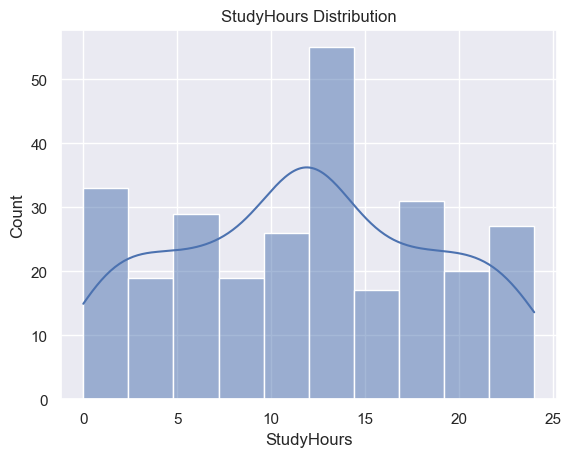

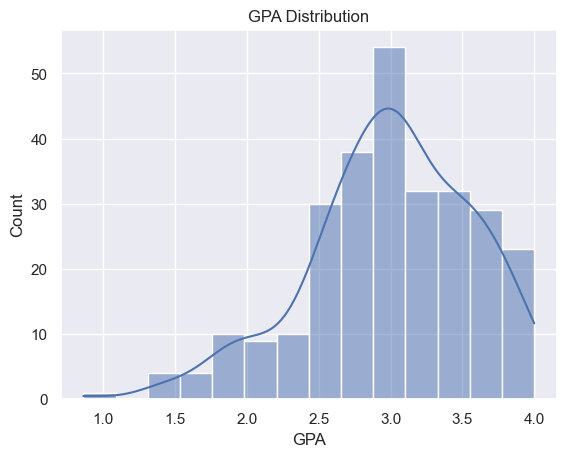

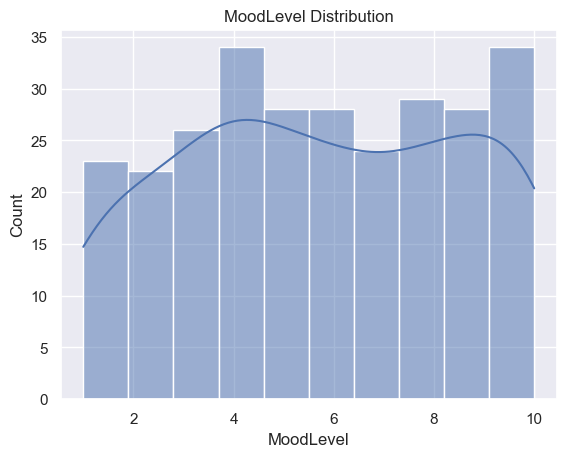

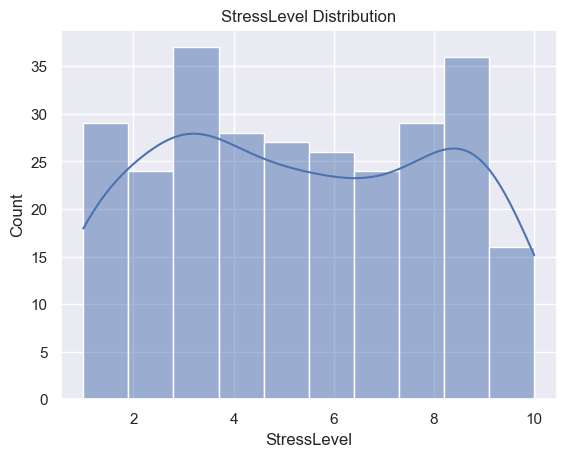

In [7]:
analyzer.univariate_analysis()

#### Univariate Analysis
Helps detect skewness and outliers.

## Bivariate & Multivariate Analysis

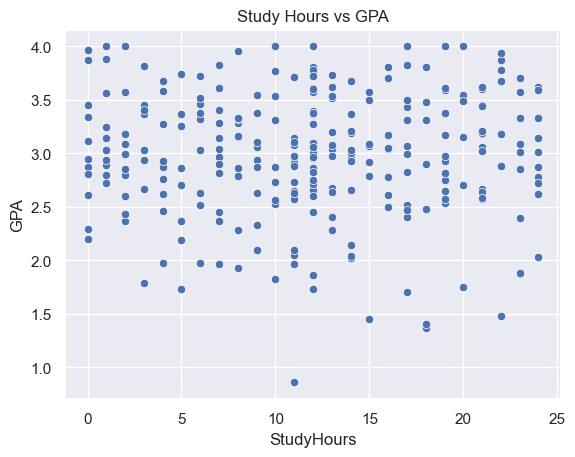

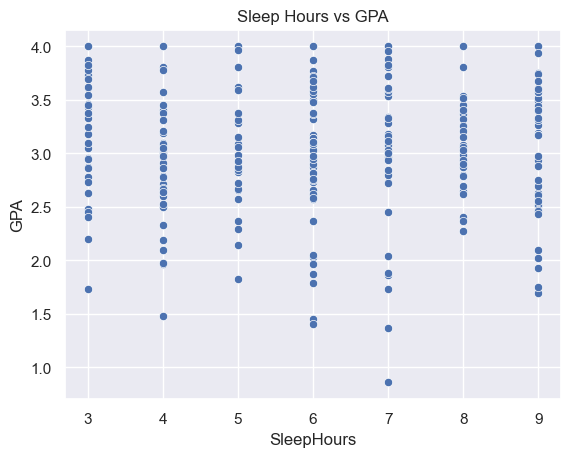

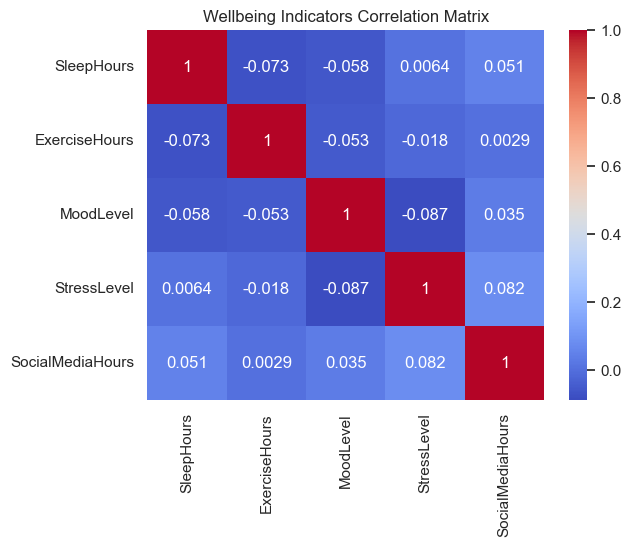

In [8]:
analyzer.bivariate_analysis()

#### Explore Relationships Between Variables
Used scatterplots and heatmaps to examine relationships:

- StudyHours vs GPA

- Correlations between Sleep, Mood, Exercise, Stress, and Social Media Use.

## Compare GPA Across Programs and Gender

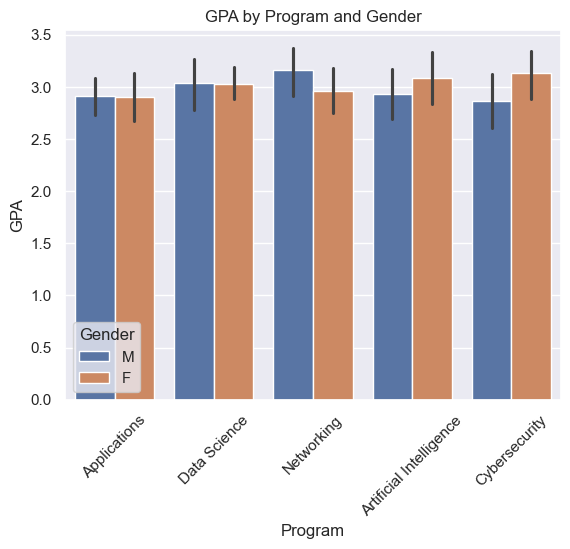

In [9]:
analyzer.compare_academic_performance()

#### Compare GPA Across Program and Gender
- Visualizes the differences in average GPA by academic program and gender using bar plots.
- Helps detect any performance gaps or trends.

In [10]:
analyzer.key_insights()


Key Insights:
1. Students who study more tend to have higher GPA.
2. Better mood and more sleep relate to lower stress.
3. Higher social media use slightly lowers WellbeingScore.
4. Female students show slightly better GPA overall.
5. Students in AI and Data Science show higher wellbeing and grades.


In [11]:
analyzer.export_cleaned_data("cleaned_student_data.csv")

Cleaned data saved to: cleaned_student_data.csv
